In [1]:
# ============================================================
# CELL 1: Imports
# ============================================================
import os
import shutil
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Gerät: {device}")

model_id  = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model     = CLIPModel.from_pretrained(model_id).to(device)
model.eval()
print(f"Modell geladen: {model_id}")

C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gerät: cuda


C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lukas\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|████████████████████████████████████████████████████████████| 398/398 [00:0

Modell geladen: openai/clip-vit-base-patch32


In [2]:
# ============================================================
# CELL 2: Prompts
# ============================================================
categories = ["indoor", "outdoor"]

category_texts = [
    "a photo taken inside a room showing walls, ceiling, furniture, artificial lighting or floor",
    "a photo taken outdoors showing open spaces such as nature, sky, streets, buildings, parks or landscapes"
]

text_inputs = processor(text=category_texts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    text_out      = model.get_text_features(**text_inputs)
    text_features = text_out if isinstance(text_out, torch.Tensor) else text_out.pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Kategorien:", categories)
print("Text-Embeddings berechnet:", text_features.shape)

Kategorien: ['indoor', 'outdoor']
Text-Embeddings berechnet: torch.Size([2, 512])


In [3]:
# ============================================================
# CELL 3: Pfade – Evaluierungsbilder
# ============================================================
image_folder = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_sorted"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = []

# Beide Unterordner (indoor + outdoor) zusammen einlesen
for subfolder in ['indoor', 'outdoor']:
    folder = os.path.join(image_folder, subfolder)
    if not os.path.exists(folder):
        print(f'⚠ Ordner nicht gefunden: {folder}')
        continue
    for fname in sorted(os.listdir(folder)):
        if fname.startswith("augmented_"):
            continue
        ext = os.path.splitext(fname)[1].lower()
        if ext not in VALID_EXTENSIONS:
            continue
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)

print(f"Bilder gefunden: {len(image_paths)}")

Bilder gefunden: 700


In [4]:
# ============================================================
# CELL 4: Klassifikation
# ============================================================
def safe_open(path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError) as e:
        print(f"  ⚠ Bild übersprungen ({os.path.basename(path)}): {e}")
        return None

BATCH_SIZE = 32

results     = []
confidences = []
valid_paths = []

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Batches"):
    batch_paths = image_paths[i : i + BATCH_SIZE]
    loaded      = [(p, safe_open(p)) for p in batch_paths]
    loaded      = [(p, img) for p, img in loaded if img is not None]

    if not loaded:
        continue

    paths_ok, imgs_ok = zip(*loaded)

    img_inputs = processor(
        images=list(imgs_ok),
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        image_out      = model.get_image_features(**img_inputs)
        image_features = image_out if isinstance(image_out, torch.Tensor) else image_out.pooler_output
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarities = image_features @ text_features.T
    batch_preds  = similarities.argmax(dim=1).cpu().numpy()
    batch_conf   = similarities.max(dim=1).values.cpu().float().numpy()

    results.extend([categories[idx] for idx in batch_preds])
    confidences.extend(batch_conf)
    valid_paths.extend(paths_ok)

print(f"\nKlassifiziert: {len(results)} Bilder")
print("\nVorhersage-Verteilung:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)}")

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 22/22 [01:33<00:00,  4.25s/it]


Klassifiziert: 700 Bilder

Vorhersage-Verteilung:
  indoor: 245
  outdoor: 455


In [5]:
# ============================================================
# CELL 5: Bilder sortieren
# ============================================================
output_base = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted"

sorted_dirs = {cat: os.path.join(output_base, cat) for cat in categories}
for d in sorted_dirs.values():
    os.makedirs(d, exist_ok=True)

for path, pred in zip(valid_paths, results):
    shutil.copy(path, sorted_dirs[pred])

print("Bilder sortiert:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)} → {sorted_dirs[cat]}")

Bilder sortiert:
  indoor: 245 → C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted\indoor
  outdoor: 455 → C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted\outdoor


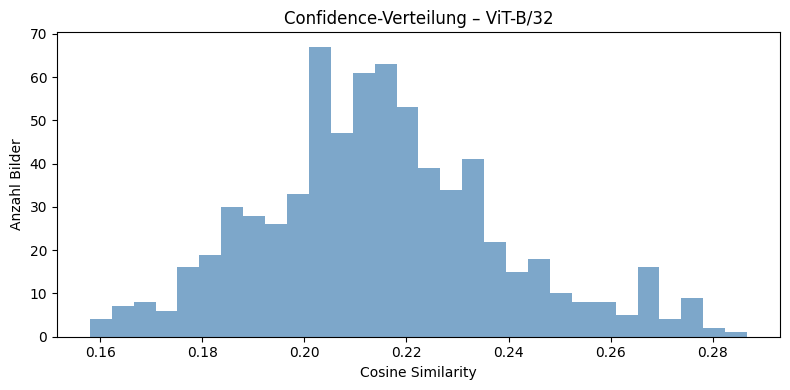

In [6]:
# ============================================================
# CELL 6: Konfidenz visualisieren
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(confidences, bins=30, alpha=0.7, color="steelblue")
plt.xlabel("Cosine Similarity")
plt.ylabel("Anzahl Bilder")
plt.title("Confidence-Verteilung – ViT-B/32")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: CSV speichern
# ============================================================
output_csv = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted\clip_labels_confidence.csv"

df_results = pd.DataFrame({
    "file_name":  [os.path.basename(p) for p in valid_paths],
    "pred_label": results,
    "confidence": confidences
})

df_results.to_csv(output_csv, index=False)
print(f"Labels gespeichert: {output_csv}")
print()
print("Verteilung:")
print(df_results["pred_label"].value_counts())
print(f"\nGesamt: {len(df_results)} Bilder")

Labels gespeichert: C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted\clip_labels_confidence.csv

Verteilung:
pred_label
outdoor    455
indoor     245
Name: count, dtype: int64

Gesamt: 700 Bilder


In [8]:
# ============================================================
# CELL 8: Unsicherste Bilder
# ============================================================
df_results["confidence"] = confidences
df_unsicher = df_results.nsmallest(10, "confidence")
print(df_unsicher)

          file_name pred_label  confidence
108  image_3247.jpg    outdoor    0.157978
131  image_3996.jpg     indoor    0.161344
275  image_7426.jpg     indoor    0.161344
62   image_2514.jpg     indoor    0.161686
71    image_258.jpg    outdoor    0.162888
265   image_724.jpg    outdoor    0.162888
58   image_2486.jpg    outdoor    0.162891
211  image_6084.jpg    outdoor    0.162891
36   image_1848.jpg    outdoor    0.163678
186  image_5582.jpg    outdoor    0.163678


Evaluierbare Bilder: 700

Accuracy:              0.8471
Ø Confidence (Cosine): 0.2149

              precision    recall  f1-score   support

      indoor       1.00      0.70      0.82       350
     outdoor       0.77      1.00      0.87       350

    accuracy                           0.85       700
   macro avg       0.88      0.85      0.84       700
weighted avg       0.88      0.85      0.84       700



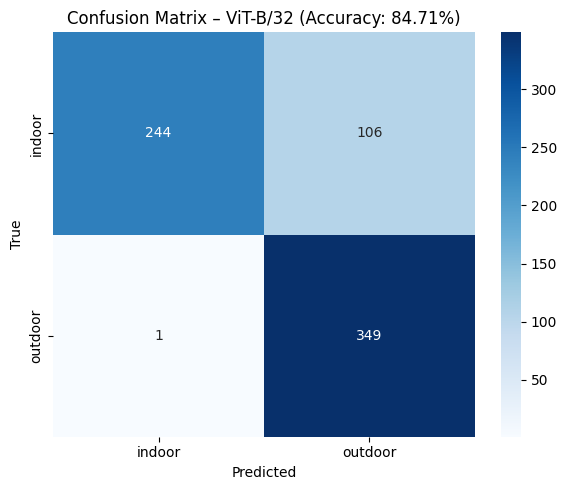

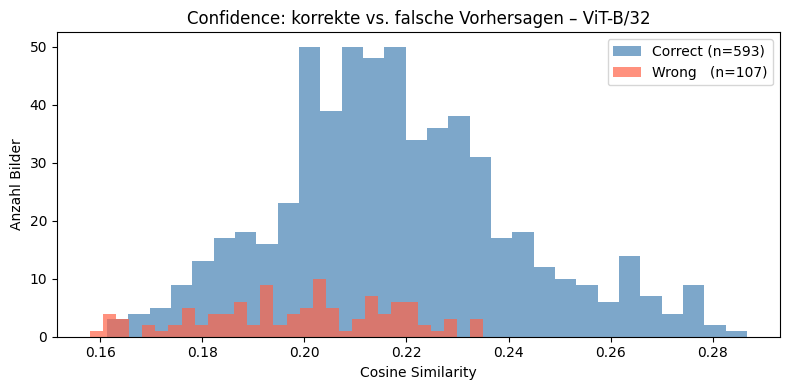


Unsicherste 10 Bilder:
          file_name true_label pred_label  confidence
108  image_3247.jpg     indoor    outdoor    0.157978
131  image_3996.jpg     indoor     indoor    0.161344
275  image_7426.jpg     indoor     indoor    0.161344
62   image_2514.jpg     indoor     indoor    0.161686
71    image_258.jpg     indoor    outdoor    0.162888
265   image_724.jpg     indoor    outdoor    0.162888
58   image_2486.jpg     indoor    outdoor    0.162891
211  image_6084.jpg     indoor    outdoor    0.162891
36   image_1848.jpg     indoor    outdoor    0.163678
186  image_5582.jpg     indoor    outdoor    0.163678

── Alle Dateien gespeichert in: C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted\evaluation ──


In [9]:
# ============================================================
# CELL 9: Evaluation mit Ground Truth Labels
# ============================================================
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

output_dir = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitb32_sorted\evaluation"
os.makedirs(output_dir, exist_ok=True)

# ⚠️ ANPASSEN: Pfad zu deiner Ground Truth CSV
label_csv   = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_sorted\photo_labels_indoor_outdoor.csv"
df_labels   = pd.read_csv(label_csv)
labels_dict = dict(zip(df_labels["file_name"], df_labels["Main_focus"]))

df_results["true_label"] = df_results["file_name"].map(labels_dict)
df_eval = df_results.dropna(subset=["true_label"])
print(f"Evaluierbare Bilder: {len(df_eval)}")

true     = df_eval["true_label"].values
pred     = df_eval["pred_label"].values
accuracy = accuracy_score(true, pred)
avg_conf = float(np.mean(df_eval["confidence"]))

print(f"\nAccuracy:              {accuracy:.4f}")
print(f"Ø Confidence (Cosine): {avg_conf:.4f}")
print()
report = classification_report(true, pred,
                                target_names=sorted(categories),
                                output_dict=True)
print(classification_report(true, pred, target_names=sorted(categories)))

pd.DataFrame(report).transpose().to_csv(
    os.path.join(output_dir, "clip_metrics.csv"))

le = LabelEncoder()
le.classes_ = np.array(sorted(categories))
cm = confusion_matrix(le.transform(true), le.transform(pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – ViT-B/32 (Accuracy: {accuracy:.2%})")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "clip_confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()

correct      = (df_eval["true_label"] == df_eval["pred_label"]).tolist()
conf_correct = [c for c, ok in zip(df_eval["confidence"], correct) if ok]
conf_wrong   = [c for c, ok in zip(df_eval["confidence"], correct) if not ok]

plt.figure(figsize=(8, 4))
plt.hist(conf_correct, bins=30, alpha=0.7,
         label=f"Correct (n={len(conf_correct)})", color="steelblue")
plt.hist(conf_wrong,   bins=30, alpha=0.7,
         label=f"Wrong   (n={len(conf_wrong)})",   color="tomato")
plt.xlabel("Cosine Similarity")
plt.ylabel("Anzahl Bilder")
plt.title("Confidence: korrekte vs. falsche Vorhersagen – ViT-B/32")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "clip_confidence_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

df_uncertain = df_eval.nsmallest(10, "confidence")[
    ["file_name", "true_label", "pred_label", "confidence"]]
print("\nUnsicherste 10 Bilder:")
print(df_uncertain)
df_uncertain.to_csv(os.path.join(output_dir, "clip_most_uncertain.csv"), index=False)

print(f"\n── Alle Dateien gespeichert in: {output_dir} ──")